<a href="https://colab.research.google.com/github/SurangaMadushan/pytorch-deep-learning-project/blob/main/notebooks/03_resnet18_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using Device:", device)

Using Device: cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

print("Training Images :", len(train_dataset))
print("Testing Images  :", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 402kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.74MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]

Training Images : 60000
Testing Images  : 10000


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train Batches :", len(train_loader))
print("Test Batches  :", len(test_loader))

Train Batches : 1875
Test Batches  : 313


In [6]:
weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 155MB/s]


In [7]:
model.fc = nn.Linear(
    model.fc.in_features,
    10
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=10, bias=True)


In [8]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

print("Only final layer will be trained.")

Only final layer will be trained.


In [9]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [10]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    accuracy = 100 * correct / total

    return epoch_loss, accuracy

In [11]:
num_epochs = 3

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    loss, acc = train_one_epoch(
        model,
        train_loader,
        loss_fn,
        optimizer,
        device
    )

    train_losses.append(loss)
    train_accuracies.append(acc)

    print(
        f"Epoch {epoch+1}/{num_epochs}"
        f" | Loss = {loss:.4f}"
        f" | Accuracy = {acc:.2f}%"
    )

Epoch 1/3 | Loss = 0.3495 | Accuracy = 90.78%
Epoch 2/3 | Loss = 0.1726 | Accuracy = 94.89%
Epoch 3/3 | Loss = 0.1500 | Accuracy = 95.39%


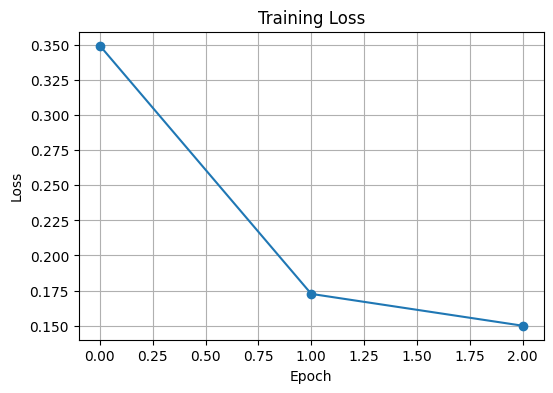

In [12]:
plt.figure(figsize=(6,4))

plt.plot(train_losses, marker="o")

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

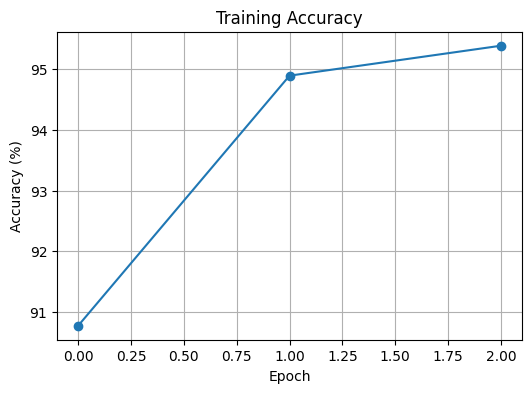

In [13]:
plt.figure(figsize=(6,4))

plt.plot(train_accuracies, marker="o")

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

In [14]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total

print(f"Test Accuracy : {test_accuracy:.2f}%")

Test Accuracy : 96.48%


In [15]:
torch.save(
    model.state_dict(),
    "resnet18_transfer_learning.pth"
)

print("Transfer Learning model saved successfully!")

Transfer Learning model saved successfully!


# Transfer Learning Summary

## Model
ResNet18 (Pre-trained on ImageNet)

## Techniques Used

- Transfer Learning
- Feature Extraction
- Frozen Layers
- Fine-tuning Final Layer

## Dataset

- MNIST
- Images resized to 224×224
- Converted from grayscale to RGB

## Results

- Epochs: 3
- Training Accuracy:
- Test Accuracy:

## Key Learning

Transfer Learning allows us to reuse knowledge from a model trained on ImageNet and adapt it quickly to a new task with minimal training.

# Transfer Learning Summary

## Model

ResNet18 (Pre-trained on ImageNet)

## Techniques Used

- Transfer Learning
- Feature Extraction
- Frozen Layers
- Fine-tuning Final Layer

## Dataset

- MNIST
- Images resized to 224 × 224
- Converted from Grayscale to RGB

## Results

- Number of Epochs: 3
- Final Training Accuracy: 95.39%
- Final Test Accuracy: 96.48%

## Key Learning

Transfer Learning reuses knowledge learned from a large dataset (ImageNet) and adapts it to a new task with minimal training. Instead of training the entire network from scratch, only the final classification layer was trained, making the process faster and more efficient.